In [49]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List,Literal
from pydantic import BaseModel, Field

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [50]:
# ----------------------------
# 1) LTM store (START EMPTY)
# ----------------------------
store = InMemoryStore()

In [51]:
# ----------------------------
# 2) System prompt
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [52]:
# ----------------------------
# 3) Memory extraction LLM
# ----------------------------
memory_llm = ChatGroq(model="llama-3.1-8b-instant",temperature=0)

In [53]:
class MemoryItem(BaseModel):
    category: str = Field(description="Memory category")
    key: str = Field(description="Unique attribute key")
    value: str = Field(description="Actual memory value")
    text: str = Field(description="Human readable memory")
    action: Literal["create", "update", "duplicate"]

In [54]:
class MemoryDecision(BaseModel):
    should_write: bool
    memories: List[MemoryItem] = Field(default_factory=list)

In [55]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [56]:
MEMORY_PROMPT = """
You are a user-memory extraction system.

Existing user memories are provided in:

{user_details_content}

Format of user_details_content:

* user_details_content is a list[dict].
* Each dictionary represents an existing memory record.
* Compare newly extracted information against these records before deciding whether it is new, updated, or already known.

Example:

[
{{
"category": "identity",
"key": "name",
"value": "Sudhanva",
"text": "User's name is Sudhanva."
}},
{{
"category": "preference",
"key": "language",
"value": "Python",
"text": "User prefers Python."
}}
]

Your task:
Analyze the user's latest message and determine whether any information should be stored as long-term memory.

Store only information that is likely to remain useful across future conversations, such as:

* Identity information
* Stable preferences
* Long-term goals
* Ongoing projects
* Recurring life context
* Persistent responsibilities
* Frequently referenced personal context

Do NOT store:

* Temporary emotions, moods, or feelings
* One-time requests
* Short-lived plans
* Session-specific context
* Information not explicitly stated by the user
* Assumptions, guesses, or inferred facts
* Generic conversational details with little future value

Memory writing rules:

* Every memory must contain exactly one fact.
* Keep memories concise and atomic.
* Write all memories as standalone third-person facts.
* Normalize first-person statements into canonical form.
* Do not include conversational wording.

Examples:

User: "I am Sudhanva"
Memory text: "User's name is Sudhanva."

User: "I live in Bangalore"
Memory text: "User lives in Bangalore."

User: "I like Python"
Memory text: "User prefers Python."

User: "I am building a RAG chatbot"
Memory text: "User is building a RAG chatbot."

MemoryItem field definitions:

* category:
  High-level memory category such as:
  identity, preference, goal, project, relationship, location, work, education, context

* key:
  Stable attribute identifier.
  Examples:
  name
  city
  favorite_language
  current_project

* value:
  Canonical value associated with the key.

* text:
  Human-readable memory written as a standalone third-person fact.

* action:
  Must be one of:

  * create
  * update
  * duplicate

Action selection rules:

create

* The fact does not exist in user_details_content.
* The information is memory-worthy and should be stored.

update

* An existing memory with the same key or meaning should be replaced or corrected.
* Use when the user provides newer, more accurate, or changed information.

duplicate

* The same fact already exists in user_details_content.
* The new information does not add anything materially different.

Deduplication rules:

* Compare semantic meaning, not exact wording.
* If an equivalent memory already exists, use duplicate.
* If a memory conflicts with an existing memory, use update.
* If the fact is entirely new, use create.

Decision rules:

* should_write = true if at least one memory has action=create or action=update.
* should_write = false if:

  * no memory-worthy information exists, or
  * all extracted memories are duplicates.

Output rules:

* Output must strictly follow the MemoryDecision schema.
* If should_write=false, return an empty memories list.
* Do not include explanations, reasoning, or additional fields.
* Return only schema-compliant data.

"""

In [57]:
# ----------------------------
# 4) Node 1: remember
# ----------------------------
def remember_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    # existing memory
    existing = store.search(ns)
    existing_items=[]
    for item in existing:
        existing_items.append(
            
                {
                "category":item.value['category'],
              "key":item.value['key'],
              "value":item.value["value"],
              "text":item.value["text"]
              }
              
              )
    # print(existing_items)
    decision:MemoryDecision=memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing_items)),
            {'role':'user','content':state["messages"][-1].content}
        ]
    )


    if decision.should_write:
        for mem in decision.memories:
            if mem.action=="create" :
                store.put(ns,str(mem.category+mem.key),{"category":mem.category,"key":mem.key,"value":mem.value,"text":mem.text})

            elif mem.action=="update":
                
                store.put(
                    ns,
                    str(mem.category+mem.key),
                    {
                        "category":mem.category,
                        "key":mem.key,
                        "value":mem.value,
                        "text":mem.text
                    }
                )

    return {}  # no message change

In [58]:
# ----------------------------
# 5) Node 2: chat
# ----------------------------
chat_llm=ChatGroq(model="llama-3.3-70b-versatile")


In [59]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    
    user_details=[]
    for item in items:
        user_details.append(
                {
                "category":item.value['category'],
              "key":item.value['key'],
              "value":item.value["value"],
              "text":item.value["text"]
              }
              
              )

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

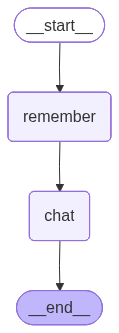

In [72]:
# ----------------------------
# 6) Graph
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember","chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [73]:
# ----------------------------
# 7) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

In [85]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Sudhanva"}]}, config)
result['messages'][-1].content

'Nice to meet you, Sudhanva. I see that I already have some information about you, including your preference for Python as a programming language, your B.Tech degree, and your career in the AIML field. How can I assist you today, Sudhanva? Are you working on a new project, or do you need help with a specific problem related to Python or AIML?\n\nHere are three potential questions to consider:\n1. What specific area of AIML are you currently focusing on, Sudhanva, such as natural language processing or computer vision?\n2. Are you using any particular Python libraries or frameworks for your AIML projects, such as TensorFlow or PyTorch?\n3. How can I help you apply your B.Tech degree and Python skills to your work in the AIML field, Sudhanva?'

In [76]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi,my favorite programming language is python"}]}, config)
result['messages'][-1].content

"Hi Sudhanva, it's great to hear that Python is your favorite programming language. As someone in the AIML field with a B.Tech degree, you must be leveraging Python's extensive libraries and simplicity to drive innovation in your projects. \n\nI recall that you've mentioned your fondness for Python before, and I'm excited to explore how we can apply its capabilities to your work in Artificial Intelligence and Machine Learning. What specific areas of AIML are you currently exploring, and how can Python be used to enhance your work?\n\nHere are three potential questions to consider:\n1. How do you think Python's popular libraries like TensorFlow or PyTorch can be used to improve your AIML projects?\n2. Are there any specific challenges you're facing in your AIML work that Python can help address?\n3. Can you think of any interesting Python-based tools or frameworks that you'd like to integrate into your current or future projects?"

In [77]:
for it in store.search(("user", "u1", "details")):
    print(it.value["text"])

User's name is Sudhanva.
User prefers Python.
User has a B.Tech degree.
User is in the AIML field.


In [78]:
result = graph.invoke({"messages": [{"role": "user", "content": "I am a btech grad in aiml"}]}, config)
print(result['messages'][-1].content)

Hi Sudhanva, great to connect with you again. As a B.Tech grad in AIML, you must be excited about the vast applications of Artificial Intelligence and Machine Learning in various industries. Your background in Python, being your favorite language, will surely come in handy in exploring the realm of AIML. 

What specific areas of AIML interest you the most, or are you working on any projects that you'd like to discuss? I'd be happy to help with any questions or provide guidance on tools and frameworks you're using, such as TensorFlow or PyTorch, which are popular in the AIML field.

Here are three further questions to continue our conversation:
1. Are you more inclined towards the theoretical aspects of AIML or its practical applications in real-world problems?
2. How do you think your Python skills will be leveraged in your AIML projects, and are there any specific libraries you're interested in exploring?
3. Are there any particular industries or domains where you'd like to apply your

In [79]:
for it in store.search(("user", "u1", "details")):
    print(it.value["text"])

User's name is Sudhanva.
User prefers Python.
User has a B.Tech degree.
User is in the AIML field.


In [80]:
result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Hi Sudhanva, I'd be happy to explain GenAI in simple terms. As someone with a background in AIML, you're likely familiar with the concept of artificial intelligence, but let me break it down for you. GenAI, or General Artificial Intelligence, refers to a type of AI that can perform any intellectual task that a human can. It's essentially a machine that can learn, reason, and apply knowledge across a wide range of tasks, much like a human being.

Think of it like this: currently, most AI systems are designed to excel in specific areas, such as image recognition, natural language processing, or playing chess. GenAI, on the other hand, aims to create a more general-purpose AI that can adapt and learn to tackle various tasks, from solving complex problems to creating art.

As a Python enthusiast, you might be interested in exploring the various libraries and frameworks that are being developed to support GenAI research. Your B.Tech degree and experience in the AIML field will likely serve 

In [81]:
for it in store.search(("user", "u1", "details")):
    print(it.value["text"])
    

User's name is Sudhanva.
User prefers Python.
User has a B.Tech degree.
User is in the AIML field.


In [82]:
result=graph.invoke({"messages":[{"role":"user","content":"my name is sunjosh"}]},config)
print(result["messages"][-1].content)

Hello again, sunjosh. It's nice to see you here. I've taken a look at your profile, and I see that you have a strong background in AIML, with a B.Tech degree and a preference for Python. How can I assist you today, perhaps with a Python-based project or an AIML-related query?

Here are three potential questions to get us started:
1. Are you currently working on any AIML projects that you'd like some guidance on, sunjosh?
2. How do you think your Python skills can be applied to your work in the AIML field?
3. Are there any specific AIML topics or techniques you're interested in learning more about, sunjosh?


In [83]:
for it in store.search(("user", "u1", "details")):
    print(it.value)
    

{'category': 'identity', 'key': 'name', 'value': 'sunjosh', 'text': "User's name is sunjosh."}
{'category': 'preference', 'key': 'favorite_language', 'value': 'python', 'text': 'User prefers Python.'}
{'category': 'education', 'key': 'degree', 'value': 'B.Tech', 'text': 'User has a B.Tech degree.'}
{'category': 'career', 'key': 'field', 'value': 'AIML', 'text': 'User is in the AIML field.'}


In [84]:
result=graph.invoke({"messages":[{"role":"user","content":"hi how are you"}]},config)
print(result["messages"][-1].content)

Hello sunjosh, I'm doing great, thanks for asking. It's lovely to interact with you again. I see that you have a background in AIML and prefer working with Python. How can I assist you today, perhaps with a project or exploring new concepts in the AIML field using your favorite language? 

Here are three potential questions to consider:
1. Are you currently working on any AIML projects in Python that you'd like some guidance on?
2. How do you think your B.Tech degree has helped you in your career in the AIML field so far?
3. Are there any specific areas within AIML, such as machine learning or deep learning, that interest you the most and you'd like to learn more about?
